# 03 - Baseline Model: TF-IDF + Logistic Regression

**Goal:** Build our first sentiment classification model.

**What we'll do:**
1. Load the cleaned data
2. Split into training and test sets
3. Convert text to numbers using TF-IDF
4. Train a Logistic Regression model
5. Evaluate how well it performs

---
## Part 1: Setup

**YOUR TASK:** Import the libraries.

You need:
- `pandas` (as pd)
- `from sklearn.model_selection import train_test_split` — splits data
- `from sklearn.feature_extraction.text import TfidfVectorizer` — converts text to numbers
- `from sklearn.linear_model import LogisticRegression` — our model
- `from sklearn.metrics import accuracy_score, classification_report, confusion_matrix` — evaluation tools

In [9]:
# YOUR CODE: Import all libraries listed above
import pandas as pd
from sklearn.model_selection import train_test_split     
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score                                                 

---
## Part 2: Load the Cleaned Data

**YOUR TASK:** Load the combined cleaned dataset we saved in Phase 2.

In [14]:
# YOUR CODE: Load combined_reviews_clean.csv from data/processed/
df = pd.read_csv('C:\\Users\\ogaga\\OneDrive\\Desktop\\Everything AI and ML\\sentiment-analysis-project\\data\\processed\\combined_reviews_clean.csv')   
df=df.dropna(subset=['clean_review', 'sentiment'])
df=df[df['clean_review'].str.strip() != '']
# Show the shape and first 5 rows
print("Shape of the dataset:", df.shape)
df.head(10)

Shape of the dataset: (238636, 4)


,clean_review,sentiment,source,review_length
0,one of the other reviewers has mentioned that ...,positive,imdb,1663
1,a wonderful little production the filming tech...,positive,imdb,936
2,i thought this was a wonderful way to spend ti...,positive,imdb,872
3,basically theres a family where a little boy j...,negative,imdb,681
4,petter matteis love in the time of money is a ...,positive,imdb,1237
5,probably my alltime favorite movie a story of ...,positive,imdb,622
6,i sure would like to see a resurrection of a u...,positive,imdb,711
7,this show was an amazing fresh innovative idea...,negative,imdb,880
8,encouraged by the positive comments about this...,negative,imdb,635
9,if you like original gut wrenching laughter yo...,positive,imdb,158


---
## Part 3: Prepare the Data

We need to separate our data into:
- **X** = the input (review text) — what the model reads
- **y** = the label (positive/negative) — what the model predicts

**YOUR TASK:** Create X and y from the DataFrame.

In [16]:
# YOUR CODE:
# X = the 'clean_review' column
# y = the 'sentiment' column
X=df['clean_review']
y=df['sentiment']  
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (238636,)
y shape: (238636,)


---
## Part 4: Train/Test Split

Split the data: 80% for training, 20% for testing.

**NEW CONCEPT: `train_test_split()`**

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

- `test_size=0.2` → 20% goes to test, 80% to train
- `random_state=42` → makes the split reproducible (same split every time you run it)

**YOUR TASK:** Write the train/test split.

In [17]:
# YOUR CODE: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} reviews")
print(f"Test set: {X_test.shape[0]} reviews")

Training set: 190908 reviews
Test set: 47728 reviews


---
## Part 5: Convert Text to Numbers (TF-IDF)

The model can't read text. TF-IDF converts each review into a vector of numbers.

**NEW CONCEPT: `TfidfVectorizer`**

```python
tfidf = TfidfVectorizer(max_features=50000)
```

- `max_features=50000` → only keep the 50,000 most important words

**Important:** We `.fit_transform()` on training data and `.transform()` on test data.

Why? The model should only learn vocabulary from training data. If it sees test data vocabulary during training, that's **data leakage** — like seeing exam answers before the test.

**YOUR TASK:** Create the TF-IDF vectors.

In [18]:
# Step 1: Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=50000)

# Step 2: Fit on training data AND transform it
# YOUR CODE: X_train_tfidf = tfidf.fit_transform(???)
X_train_tfidf = tfidf.fit_transform(X_train)

# Step 3: Only transform test data (don't fit again!)
# YOUR CODE: X_test_tfidf = tfidf.transform(???)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF training matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF test matrix shape: {X_test_tfidf.shape}")
print(f"\nThis means: {X_train_tfidf.shape[0]} reviews, each represented by {X_train_tfidf.shape[1]} features")

TF-IDF training matrix shape: (190908, 50000)
TF-IDF test matrix shape: (47728, 50000)

This means: 190908 reviews, each represented by 50000 features


---
## Part 6: Train the Model

Now we train Logistic Regression on the TF-IDF features.

**YOUR TASK:** Create and train the model.

```python
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
```

- `max_iter=1000` → gives the model enough iterations to converge (find the best solution)
- `.fit()` → this is where the actual learning happens

In [20]:
# YOUR CODE: Create and train the Logistic Regression model
model=LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Model training complete!")

Model training complete!


---
## Part 7: Make Predictions

Use the trained model to predict sentiment on the **test set** (data it has never seen).

**YOUR TASK:** Generate predictions.

In [22]:
# YOUR CODE: Use model.predict() on the test TF-IDF data
# y_pred = model.predict(???)
y_pred = model.predict(X_test_tfidf)    
print(f"Predictions made for {len(y_pred)} reviews")
print(f"\nFirst 10 predictions: {y_pred[:10]}")
print(f"First 10 actual:      {y_test[:10].values}")

Predictions made for 47728 reviews

First 10 predictions: ['positive' 'negative' 'negative' 'positive' 'positive' 'negative'
 'negative' 'positive' 'positive' 'negative']
First 10 actual:      ['positive' 'negative' 'negative' 'positive' 'positive' 'negative'
 'negative' 'positive' 'positive' 'negative']


---
## Part 8: Evaluate the Model

How well did our model do?

**Key Metrics:**
- **Accuracy** — What % of predictions were correct?
- **Precision** — When it said 'positive', how often was it right?
- **Recall** — Of all actual positives, how many did it catch?
- **F1 Score** — Balance between precision and recall

**YOUR TASK:** Print the accuracy and classification report.

In [23]:
# Accuracy
# YOUR CODE: accuracy = accuracy_score(y_test, y_pred)
accuracy_score = accuracy_score(y_test, y_pred)
accuracy = accuracy_score
print(f"Accuracy: {accuracy:.4f}")
print(f"This means the model got {accuracy*100:.1f}% of predictions correct.")

Accuracy: 0.9145
This means the model got 91.4% of predictions correct.


In [ ]:
# Classification Report — shows precision, recall, F1 for each class
# YOUR CODE: print(classification_report(y_test, y_pred))



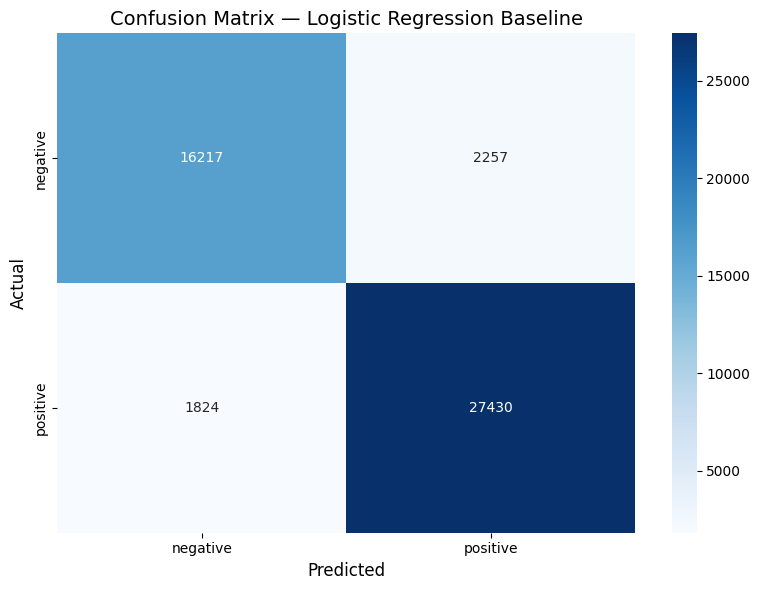


How to read this:
  True Negatives (correct): 16217
  False Positives (wrong):  2257
  False Negatives (wrong):  1824
  True Positives (correct): 27430


In [24]:
# Confusion Matrix — shows where the model got confused
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix — Logistic Regression Baseline', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_baseline.png', dpi=150)
plt.show()

print("\nHow to read this:")
print(f"  True Negatives (correct): {cm[0][0]}")
print(f"  False Positives (wrong):  {cm[0][1]}")
print(f"  False Negatives (wrong):  {cm[1][0]}")
print(f"  True Positives (correct): {cm[1][1]}")

---
## Part 9: Test With Your Own Reviews

Let's see if the model works on reviews you write yourself.

In [25]:
# Try your own reviews!
# Write any review and see what the model predicts

my_reviews = [
    "This product is absolutely amazing, I love it!",
    "Terrible experience, worst purchase I ever made.",
    "It was okay, nothing special but not bad either.",
    "The quality is outstanding and the price is fair.",
    "Broke after two days. Total waste of money."
]

# Transform using the SAME tfidf vectorizer (important!)
my_reviews_tfidf = tfidf.transform(my_reviews)

# Predict
my_predictions = model.predict(my_reviews_tfidf)

# Show results
print("=" * 60)
for review, pred in zip(my_reviews, my_predictions):
    print(f"Review:     {review}")
    print(f"Prediction: {pred}")
    print("-" * 60)

Review:     This product is absolutely amazing, I love it!
Prediction: positive
------------------------------------------------------------
Review:     Terrible experience, worst purchase I ever made.
Prediction: negative
------------------------------------------------------------
Review:     It was okay, nothing special but not bad either.
Prediction: negative
------------------------------------------------------------
Review:     The quality is outstanding and the price is fair.
Prediction: positive
------------------------------------------------------------
Review:     Broke after two days. Total waste of money.
Prediction: negative
------------------------------------------------------------


---
## Part 10: Save the Model

Save the trained model so we don't have to retrain it every time.

**NEW CONCEPT: `joblib`**

joblib saves Python objects (like our model) to a file.

In [26]:
import joblib

# Save the model and the TF-IDF vectorizer
# We need BOTH to make predictions later
joblib.dump(model, '../models/logistic_regression_baseline.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Model saved to models/logistic_regression_baseline.pkl")
print("TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl")

Model saved to models/logistic_regression_baseline.pkl
TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl


---
## Summary

Fill this in:

1. **Model:** Logistic Regression with TF-IDF features
2. **Training set size:** _____ reviews
3. **Test set size:** _____ reviews
4. **Accuracy:** _____% 
5. **Best at predicting:** positive or negative?
6. **Custom review test:** Did it get them right?

### Questions to think about:
- Is this accuracy good enough for a real product?
- What types of reviews did it get wrong?
- Could a more complex model do better?
- What happens with neutral/sarcastic reviews?